# Does single-token fraction predict the English detour?

Wendler et al. (2024) §6 conjecture that the English "detour" in multilingual
transformers is weaker where the target language has **single-token words**:

> Where language-specific tokens are available, the detour through English seems
> less pronounced.

Their evidence is four languages with different single-token fractions (zh 100%,
fr 55%, de 43%, ru 13%). That correlation confounds tokenization with everything
else separating those languages — script, morphology, corpus share, competence.

This notebook tests the conjecture two ways, both of which break that confound:

1. **Across languages, one model.** The usual comparison, rebuilt on models
   Wendler never used. One kernel session produces this.
2. **Across models, one language.** The same word list has a different
   single-token fraction on each tokenizer — Llama-3 is 128k, Gemma-2 is 256k.
   Language, word list, prompt, and scoring are held fixed while single-token
   fraction moves. **This is the cleaner test.**

Measured for each (model, language): peak P(English), and the area under the
English curve. The companion notebook found that peak *height* and total English
can separate two conditions in **opposite** directions, so both are reported and
neither is treated as *the* answer.

## How to run this

**One model per kernel session.** Loading a second model into a kernel that has
already held one produced a model whose lens did not reproduce its own output;
the gate caught it, and the same model loaded alone verifies to four decimals.
So: pick a model in the `MODEL` cell, Restart → Run All, run the emit cell at the
bottom, save the notebook. Then restart, pick the next model, repeat.

Comparison (2) therefore cannot happen inside the notebook — no single session
ever sees two tokenizers. It is computed locally instead:

```
python extract_results.py tokenization_vs_detour.ipynb   # after each session
python tokenization_analysis.py                          # once, over all of them
```

Arrays are keyed by model, so sessions accumulate rather than overwrite.

Prerequisite: `mechanistic_interpretability.ipynb` — the lens, the `Start(w)`
scoring, and the verification gates are the same and are not re-explained here.

In [1]:
%pip install -q --no-deps "transformer_lens<3"
%pip install -q "transformers>=4.44,<5" einops fancy_einsum jaxtyping beartype rich better-abc accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.9/239.9 kB 5.5 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.2 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformer-lens 2.18.0 requires transformers-stream-generator<0.0.6,>=0.0.5, which is not installed.
transformer-lens 2.18.0 requires beartype<0.15.0,>=0.14.1, but you have beartype 0.22.9 which is incompatible.
transformer-lens 2.18.0 requires numpy<2,>=1.26; python_version == "3.12", but you have numpy 2.0.2 which is incompatible.
Note: you m

### Restart the kernel after the cell above

Pip replacing packages on disk does not change what is already loaded in memory.
Run the install once per session, restart, then continue from here.

In [1]:
import numpy, transformers, transformer_lens
import importlib.metadata as md
print("numpy           ", numpy.__version__)
print("transformers    ", transformers.__version__)
print("transformer_lens", md.version("transformer_lens"))

numpy            2.0.2
transformers     4.57.6
transformer_lens 2.18.0


In [2]:
import torch, gc
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))
print(f"total VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

True Tesla T4
total VRAM: 15.6 GB


In [3]:
import os, getpass
from pathlib import Path

os.environ["HF_HOME"]  = "/tmp/hf"
os.environ["HF_TOKEN"] = os.environ.get("HF_TOKEN") or getpass.getpass("HF token: ")

OUT = Path(os.environ.get("OUT_DIR", "/kaggle/working"))
OUT.mkdir(parents=True, exist_ok=True)
print("results ->", OUT)

results -> /kaggle/working


## Word list

54 concrete concepts. English is the pivot and is always scored; every other
language is a target in its own repetition task.

⚠️ **These translations need checking before the results mean anything.** They
were assembled for this experiment, not drawn from a validated corpus. Two known
hazards:

- **Korean homonyms.** 눈 is both *eye* and *snow*; 차 is both *car* and *tea*;
  말 is both *horse* and *word*. The behavioural check will show the model
  producing a defensible answer that is not the one being scored.
- **Simplified vs traditional Chinese.** Japanese kanji track traditional forms,
  mainland Chinese uses simplified — 魚/鱼, 車/车, 馬/马. Both are listed where
  they differ so the shared-character subset can be identified.

The behavioural check per language is the safety net: a mistranslation shows up
as low accuracy, not as a wrong curve. Read it before reading any sweep.

In [4]:
# concept: (en, ja, zh, de, ru, ko)
WORDS = [
    ("flower",   "花",  "花",   "Blume",   "цветок",   "꽃"),
    ("dog",      "犬",  "狗",   "Hund",    "собака",   "개"),
    ("mountain", "山",  "山",   "Berg",    "гора",     "산"),
    ("water",    "水",  "水",   "Wasser",  "вода",     "물"),
    ("book",     "本",  "书",   "Buch",    "книга",    "책"),
    ("house",    "家",  "房子", "Haus",    "дом",      "집"),
    ("moon",     "月",  "月亮", "Mond",    "луна",     "달"),
    ("fish",     "魚",  "鱼",   "Fisch",   "рыба",     "물고기"),
    ("bird",     "鳥",  "鸟",   "Vogel",   "птица",    "새"),
    ("tree",     "木",  "树",   "Baum",    "дерево",   "나무"),
    ("eye",      "目",  "眼睛", "Auge",    "глаз",     "눈"),
    ("car",      "車",  "车",   "Auto",    "машина",   "자동차"),
    ("king",     "王",  "王",   "König",   "король",   "왕"),
    ("snow",     "雪",  "雪",   "Schnee",  "снег",     "눈"),
    ("salt",     "塩",  "盐",   "Salz",    "соль",     "소금"),
    ("stone",    "石",  "石头", "Stein",   "камень",   "돌"),
    ("blood",    "血",  "血",   "Blut",    "кровь",    "피"),
    ("egg",      "卵",  "蛋",   "Ei",      "яйцо",     "알"),
    ("shoe",     "靴",  "鞋",   "Schuh",   "туфля",    "신발"),
    ("ship",     "船",  "船",   "Schiff",  "корабль",  "배"),
    ("summer",   "夏",  "夏天", "Sommer",  "лето",     "여름"),
    ("silver",   "銀",  "银",   "Silber",  "серебро",  "은"),
    ("road",     "道",  "路",   "Straße",  "дорога",   "길"),
    ("sky",      "空",  "天空", "Himmel",  "небо",     "하늘"),
    ("fire",     "火",  "火",   "Feuer",   "огонь",    "불"),
    ("star",     "星",  "星",   "Stern",   "звезда",   "별"),
    ("sea",      "海",  "海",   "Meer",    "море",     "바다"),
    ("river",    "川",  "河",   "Fluss",   "река",     "강"),
    ("rain",     "雨",  "雨",   "Regen",   "дождь",    "비"),
    ("foot",     "足",  "脚",   "Fuß",     "нога",     "발"),
    ("head",     "頭",  "头",   "Kopf",    "голова",   "머리"),
    ("mouth",    "口",  "嘴",   "Mund",    "рот",      "입"),
    ("ear",      "耳",  "耳朵", "Ohr",     "ухо",      "귀"),
    ("tooth",    "歯",  "牙",   "Zahn",    "зуб",      "이"),
    ("meat",     "肉",  "肉",   "Fleisch", "мясо",     "고기"),
    ("rice",     "米",  "米",   "Reis",    "рис",      "쌀"),
    ("tea",      "茶",  "茶",   "Tee",     "чай",      "차"),
    ("iron",     "鉄",  "铁",   "Eisen",   "железо",   "철"),
    ("paper",    "紙",  "纸",   "Papier",  "бумага",   "종이"),
    ("window",   "窓",  "窗",   "Fenster", "окно",     "창문"),
    ("bridge",   "橋",  "桥",   "Brücke",  "мост",     "다리"),
    ("island",   "島",  "岛",   "Insel",   "остров",   "섬"),
    ("ice",      "氷",  "冰",   "Eis",     "лёд",      "얼음"),
    ("light",    "光",  "光",   "Licht",   "свет",     "빛"),
    ("color",    "色",  "颜色", "Farbe",   "цвет",     "색"),
    ("voice",    "声",  "声音", "Stimme",  "голос",    "목소리"),
    ("bone",     "骨",  "骨头", "Knochen", "кость",    "뼈"),
    ("face",     "顔",  "脸",   "Gesicht", "лицо",     "얼굴"),
    ("hair",     "髪",  "头发", "Haar",    "волосы",   "머리카락"),
    ("horse",    "馬",  "马",   "Pferd",   "лошадь",   "말"),
    ("cow",      "牛",  "牛",   "Kuh",     "корова",   "소"),
    ("cat",      "猫",  "猫",   "Katze",   "кошка",    "고양이"),
    ("cloud",    "雲",  "云",   "Wolke",   "облако",   "구름"),
    ("forest",   "森",  "森林", "Wald",    "лес",      "숲"),
]

LANGS = ["en", "ja", "zh", "de", "ru", "ko"]
COL   = {l: i for i, l in enumerate(LANGS)}          # index into each tuple

# Endonyms, following Wendler's convention of naming the language in itself.
LABEL = {"en": "English", "ja": "日本語", "zh": "中文",
         "de": "Deutsch", "ru": "русский", "ko": "한국어"}

# Targets to sweep. English is the pivot being measured, never a target.
TARGETS = ["ja", "zh", "de", "ru", "ko"]

print(len(WORDS), "concepts x", len(LANGS), "languages")
shared = [w for w in WORDS if w[COL["ja"]] == w[COL["zh"]]]
print(f"{len(shared)} concepts written identically in JA and ZH:",
      " ".join(w[COL['ja']] for w in shared))

54 concepts x 6 languages
17 concepts written identically in JA and ZH: 花 山 水 王 雪 血 船 火 星 海 雨 肉 米 茶 光 牛 猫


In [5]:
# Word-list validation. Runs without a model -- do this before spending GPU time.
import collections

print("duplicate targets within a language (a homonym enters the sweep twice as")
print("if it were two independent words, so one copy is dropped later):")
any_dup = False
for lg in LANGS:
    i = COL[lg]
    for word, n in collections.Counter(w[i] for w in WORDS).items():
        if n > 1:
            any_dup = True
            print(f"   {lg}: {word!r} <- {[w[0] for w in WORDS if w[i] == word]}")
print("   none" if not any_dup else "")

blank = [(w[0], lg) for w in WORDS for lg in LANGS if not w[COL[lg]].strip()]
print(f"\nmissing translations: {blank if blank else 'none'}")
print(f"tuple widths: {set(len(w) for w in WORDS)} (must be {{{len(LANGS)}}})")

duplicate targets within a language (a homonym enters the sweep twice as
if it were two independent words, so one copy is dropped later):
   ko: '눈' <- ['eye', 'snow']


missing translations: none
tuple widths: {6} (must be {6})


The shared JA/ZH characters printed above are worth noting: for those concepts
the target token is *identical* between the two languages, so single-token
availability is held exactly constant and only the language framing of the
prompt differs. Any difference in the English detour on that subset cannot be
tokenization. It is analysed at the end.

In [6]:
import random

def make_repeat_prompt(target, examples, lang, n_shot=4, seed=0):
    '''XX -> XX repetition, the task where Wendler's tokenization claim lives.'''
    rng = random.Random(seed)
    i    = COL[lang]
    lab  = LABEL[lang]
    shots = rng.sample([e for e in examples if e[i] != target], n_shot)
    lines = [f"{lab}: {e[i]} - {lab}: {e[i]}" for e in shots]
    lines.append(f"{lab}: {target} - {lab}:")
    return "\n".join(lines)


# The translation half of the design. The SOURCE language is held fixed while the
# TARGET language varies, so the independent variable -- the target's single-token
# fraction -- moves and the source does not.
#
# Japanese is the source because the companion notebook measured JA->DE, which makes
# one cell of this sweep directly comparable to Phase 1 rather than a fresh design
# with nothing to check it against.
#
# English is never a source and never a target: it is the pivot being measured, and
# putting it on either end of the prompt would make the measurement circular.
SRC_LANG = "ja"

def make_translate_prompt(concept, examples, tgt_lang, src_lang=SRC_LANG,
                          n_shot=4, seed=0):
    '''SRC -> TGT translation, mirroring the companion notebook's JA->DE design.

    Takes the whole concept tuple rather than a single word, because a translation
    prompt needs both ends: the source form to show, and the target form to elicit.
    '''
    rng    = random.Random(seed)
    si, ti = COL[src_lang], COL[tgt_lang]
    sl, tl = LABEL[src_lang], LABEL[tgt_lang]
    shots  = rng.sample([e for e in examples if e[ti] != concept[ti]], n_shot)
    lines  = [f"{sl}: {e[si]} - {tl}: {e[ti]}" for e in shots]
    lines.append(f"{sl}: {concept[si]} - {tl}:")
    return "\n".join(lines)


def make_prompt(concept, lang, task, seed=0):
    '''Single entry point, so no caller can build a prompt for the wrong task.'''
    if task == "repeat":
        return make_repeat_prompt(concept[COL[lang]], WORDS, lang, seed=seed)
    if task == "translate":
        return make_translate_prompt(concept, WORDS, lang, seed=seed)
    raise ValueError(f"unknown task {task!r}")


print("=== repetition ===")
print(make_repeat_prompt(WORDS[0][COL["ja"]], WORDS, "ja"))
print("\n=== translation (JA -> DE) ===")
print(make_translate_prompt(WORDS[0], WORDS, "de"))
print("\n=== translation (JA -> KO) ===")
print(make_translate_prompt(WORDS[0], WORDS, "ko"))

=== repetition ===
日本語: 星 - 日本語: 星
日本語: 馬 - 日本語: 馬
日本語: 川 - 日本語: 川
日本語: 水 - 日本語: 水
日本語: 花 - 日本語:

=== translation (JA -> DE) ===
日本語: 星 - Deutsch: Stern
日本語: 馬 - Deutsch: Pferd
日本語: 川 - Deutsch: Fluss
日本語: 水 - Deutsch: Wasser
日本語: 花 - Deutsch:

=== translation (JA -> KO) ===
日本語: 星 - 한국어: 별
日本語: 馬 - 한국어: 말
日本語: 川 - 한국어: 강
日本語: 水 - 한국어: 물
日本語: 花 - 한국어:


## Scoring and the lens

Identical to the companion notebook: `Start(w)` prefix summation over the whole
vocabulary, and a hand-rolled logit lens with the final norm applied and any
logit soft-cap reapplied. Both are rebuilt per model, because the vocabulary and
the soft-cap setting differ between families.

In [7]:
def build_vocab_strs(model):
    '''Decoded vocabulary. SentencePiece marks a leading space U+2581, BPE uses U+0120.'''
    toks = model.tokenizer.convert_ids_to_tokens(list(range(model.cfg.d_vocab)))
    out  = []
    for t in toks:
        if not isinstance(t, str):
            out.append("")
        else:
            out.append(t.replace("▁", " ").replace("Ġ", " "))
    return out


def start_token_ids(model, vocab_strs, word):
    '''Every vocab token that could begin `word` (Wendler et al., Appendix A.2).'''
    ids = set()
    for s in (word, " " + word):
        toks = model.to_tokens(s, prepend_bos=False)[0]
        if len(toks):
            ids.add(toks[0].item())
    spaced = " " + word
    for i, vs in enumerate(vocab_strs):
        if vs.strip() and (word.startswith(vs) or spaced.startswith(vs)):
            ids.add(i)
    return ids


def n_tokens(model, word):
    return len(model.to_str_tokens(" " + word, prepend_bos=False))

In [8]:
def lens_probs(model, prompt, id_sets):
    """Logit lens. Returns (probs [n_rows, n_sets], labels).

    Wendler et al. §3.2 define the lens as treating an intermediate latent "as if
    it were a final-layer latent" -- each latent gets the model's OWN final norm,
    computed from that latent, then the model's own unembedding. That is exactly
    `ln_final` then `unembed`, which is what HookedTransformer.forward() does to
    the last latent; the lens applies it to all of them.

    cache.apply_ln_to_stack() is deliberately NOT used. Its `recompute_ln` argument
    defaults to False, and in that mode it scales every component by the *final*
    layer's cached scale so contributions sum linearly to the real logits --
    correct for logit attribution, wrong for a lens. The final row is identical
    either way, which is why a verification that only checks the last row cannot
    tell them apart. (TransformerLens 2.18 does expose the lens convention, as
    accumulated_resid(apply_ln=True) -> recompute_ln=True. This is equivalent and
    kept explicit so the normalisation is visible at the call site.)
    """
    with torch.no_grad():
        _, cache = model.run_with_cache(prompt)
        resid, labels = cache.accumulated_resid(layer=-1, incl_mid=False, return_labels=True)
        h = resid[:, 0, -1, :].unsqueeze(0)          # [1, n_rows, d_model], un-normalised
        del cache

        h = model.ln_final(h)                        # per-latent, not a cached scale

        # Wendler §3.1: RMS normalisation places every latent on a hypersphere of
        # radius sqrt(d) -- but only when the norm carries no weights. That holds
        # under fold_ln=True (the from_pretrained default), where ln_final is a
        # parameter-free "Pre" variant whose weights have been folded into W_U.
        # Under from_pretrained_no_processing the weights are still on ln_final and
        # rescale each dimension, so the radius is legitimately not 1 and asserting
        # it would reject a correct lens. Hence: check which module we actually got.
        folded = not hasattr(model.ln_final, "w")
        if folded:
            radius = h[0].norm(dim=-1) / model.cfg.d_model ** 0.5
            assert (radius - 1).abs().max() < 0.05, (
                f"post-norm radius {radius.min():.3f}-{radius.max():.3f}, expected 1.0"
                f" -- the final norm is misapplied for {model.cfg.model_name}")

        lg = model.unembed(h)[0].float()             # z = U h, includes b_U

        # Gemma-2 soft-caps logits inside forward(); model.unembed bypasses that
        # path. Compared against 0.0, not None: HookedTransformerConfig always
        # defines this field and defaults it to 0.0 -- which is what forward()
        # itself tests -- so an `is not None` test would divide by zero on Llama.
        cap = getattr(model.cfg, "output_logits_soft_cap", 0.0) or 0.0
        if cap > 0.0:
            lg = cap * torch.tanh(lg / cap)

        p = lg.softmax(-1)
        out = torch.stack([p[:, list(s)].sum(-1) for s in id_sets], dim=-1).cpu()

    gc.collect(); torch.cuda.empty_cache()
    return out, labels

## Models

One model at a time — a T4 cannot hold two. Vocabulary size is the point of the
comparison, so it is recorded alongside every result.

`meta-llama/Llama-2-7b-hf` is gated on Hugging Face and needs an approved
licence request; it is also ~13.5 GB in bf16, which is tight on a 16 GB T4. The
Llama-3.2 models are smaller and are the safe default. Drop or add entries here
rather than editing anything below.

In [9]:
# ONE MODEL PER KERNEL SESSION.
#
# Vocabulary size is the independent variable, so models are chosen to span it:
# Llama-3.2 is 128k, Gemma-2 is 256k. Llama-3.2-3B shares the 1B's tokenizer
# exactly, which makes it a scale control: any difference between them is not
# tokenization.
#
# Names must appear in TransformerLens's registry -- TinyLlama does not, which is
# what aborted an earlier run. Check with:
#   from transformer_lens.loading_from_pretrained import OFFICIAL_MODEL_NAMES
#
# WHY ONE AT A TIME: a T4 cannot hold two of these at once, and results are tagged
# by model so sessions merge on their own. (An earlier note here blamed load ORDER
# for the Llama gate failure. That was wrong and is recorded as wrong: Llama-3.2-1B
# was then run first and alone in a fresh kernel and failed identically. Order is
# not the variable. The gate now retries on the second TransformerLens load path
# before refusing, which is the actual remaining difference between the two models
# -- see load_verified.)
#
# Uncomment ONE. Run the notebook. Then restart, switch, and run it again.
MODEL = "google/gemma-2-2b"            # 256k vocab -- repetition DONE and extracted;
                                       # translation still missing
# MODEL = "meta-llama/Llama-3.2-1B"    # 128k vocab -- tied embeddings, no lm_head
                                       # in the checkpoint; gate refuses it on the
                                       # default load path, retries unprocessed
# MODEL = "meta-llama/Llama-3.2-3B"    # 128k vocab, same tokenizer as 1B (scale control)
# MODEL = "Qwen/Qwen2.5-1.5B"          # 151k. Heavily Chinese-trained, so a Qwen point
#                                      # on the zh line confounds tokenizer with training
#                                      # exposure -- the exact confound this notebook
#                                      # exists to break. Enable only for non-zh languages.

MODELS  = [MODEL]
N_SEEDS = 3

# BOTH TASKS. The design is (models x languages x tasks); running only repetition
# answers the tokenization question for one of the two conditions and leaves the
# other half of the design empty, which is what happened for the whole first pass.
#
# Trim this to run only the missing half. gemma-2-2b's repetition cells are already
# extracted, so a gemma session needs TASKS = ["translate"] and nothing else.
TASKS = ["translate"]


def targets_for(task):
    '''Which target languages a task sweeps.

    Translation cannot target its own source language: JA->JA is the repetition
    condition, not a translation, and including it would put the same cell in both
    halves of the design under two different names.
    '''
    return [l for l in TARGETS if not (task == "translate" and l == SRC_LANG)]


assert len(MODELS) == 1, "one model per kernel; run the notebook again for the next"
assert all(t in ("repeat", "translate") for t in TASKS), f"bad TASKS: {TASKS}"

n_pass = sum(len(targets_for(t)) for t in TASKS) * len(WORDS) * N_SEEDS
print(f"{MODEL}")
print(f"  tasks   : {TASKS}")
for t in TASKS:
    print(f"     {t:<10} -> {targets_for(t)}")
print(f"  {len(WORDS)} words x {N_SEEDS} seeds")
print(f"  ~{n_pass} forward passes this session (before per-language drops)")

google/gemma-2-2b
  tasks   : ['translate']
     translate  -> ['zh', 'de', 'ru', 'ko']
  54 words x 3 seeds
  ~648 forward passes this session (before per-language drops)


In [10]:
import numpy as np
import traceback
from transformer_lens import HookedTransformer

def load(name, processing=True):
    """Load a model. `processing` selects which TransformerLens load path.

    processing=True  -> from_pretrained: folds ln_final's weights into W_U, centres
                        the unembedding, folds value biases. The default, and what
                        every result so far was produced with.
    processing=False -> from_pretrained_no_processing: none of that. TransformerLens
                        itself warns on every bf16 load that this is the advisable
                        path at reduced precision, and the folding step is the only
                        thing that touches W_U before the lens ever sees it.

    Both are legitimate lenses. The folded path makes Wendler's sqrt(d) invariant
    checkable; the unfolded path keeps the norm weights on ln_final, so the
    invariant does not apply but the arithmetic is otherwise identical. Which path
    a model ended up on is recorded in its results and must be disclosed.
    """
    held = torch.cuda.memory_allocated() / 1e9
    if held > 0.5:
        print(f"   note: {held:.2f} GB already allocated before loading.")
    fn = HookedTransformer.from_pretrained if processing \
        else HookedTransformer.from_pretrained_no_processing
    m = fn(name, device="cuda", dtype=torch.bfloat16)
    m.eval()
    return m


def unload(m):
    """Free a model's GPU memory. Call as `model = unload(model)`.

    `del m` inside a function only drops that function's local name, so the
    caller's variable still holds the model. Hence: move the weights to CPU first,
    which releases the GPU allocation even if a reference survives, and return
    None so the caller rebinds its own name.
    """
    try:
        m.cpu()
    except Exception:
        pass
    del m
    gc.collect(); torch.cuda.empty_cache()
    return None


def lens_agreement(model, lang="de"):
    """Final-row lens-vs-model agreement. Returns (lens, real, ids, vocab_strs, note).

    Every failure mode is returned, never raised. lens_probs asserts Wendler's
    sqrt(d) invariant, and an assertion escaping this function would abort the
    whole run at the sweep cell -- which is precisely how an earlier session ended
    with a refusal and no diagnosis, because the diagnostic cell sits *after* the
    sweep and never got to execute. A gate that cannot fail softly is not a gate,
    it is a landmine.
    """
    try:
        vs   = build_vocab_strs(model)
        word = WORDS[0][COL[lang]]
        ids  = sorted(start_token_ids(model, vs, word))
        p    = make_repeat_prompt(word, WORDS, lang, seed=0)
        pr, labels = lens_probs(model, p, [ids])
        lens = pr[-1, 0].item()
        real = model(p)[0, -1].float().softmax(-1)[ids].sum().item()
        return lens, real, ids, vs, f"{len(labels)} rows"
    except Exception as e:
        return None, None, [], None, f"{type(e).__name__}: {e}"


def load_verified(name, lang="de"):
    """Load `name` and return (model, vocab_strs, mode) with a lens that works.

    The gate this notebook was missing. The lens must reproduce the model's own
    output distribution or nothing measured through it means anything. It does NOT
    prove the token ids are right -- both sides index the same ids, so a wrong id
    passes silently -- but it does prove the norm/unembed/soft-cap path is wired
    correctly for the model object actually in memory.

    On failure it does not give up: it reloads on the other TransformerLens path
    before refusing. Llama-3.2-1B fails the default path here while Gemma-2 passes
    it, and the two differ in exactly one relevant respect -- Llama-3.2 ships with
    *tied* embeddings, so its checkpoint contains no lm_head.weight and W_U is
    derived from the embedding matrix, which the folding step then rescales. A
    second attempt costs one reload; skipping it costs the model entirely.

    Returns vocab_strs=None if both paths fail, with `model` still returned so the
    diagnostic cell can inspect it.
    """
    model = None
    for processing in (True, False):
        mode = "from_pretrained" if processing else "from_pretrained_no_processing"
        try:
            model = load(name, processing=processing)
        except Exception as e:
            print(f"  load [{mode}] raised {type(e).__name__}: {e}")
            continue

        lens, real, ids, vs, note = lens_agreement(model, lang)
        if lens is None:
            print(f"  lens check [{mode}]: RAISED -- {note}")
            ok = False
        else:
            ok = abs(lens - real) <= 0.05 * max(real, 1e-6) + 1e-4
            print(f"  lens check [{mode}]: lens {lens:.4f}  model {real:.4f}  "
                  f"{note}  {len(ids)} ids  {'OK' if ok else 'MISMATCH'}")
        if ok:
            if not processing:
                print("   NOTE: verified on the UNPROCESSED path. The lens reproduces the")
                print("   model's own output, but ln_final keeps its weights here so the")
                print("   sqrt(d) invariant does not apply, and this model's load path")
                print("   differs from the others. This must be disclosed in the write-up.")
            return model, vs, mode
        if processing:
            print("   retrying on from_pretrained_no_processing before refusing ...")
            model = unload(model)

    print("   REFUSED: neither load path gives a lens that reproduces this model.")
    return model, None, None

## The per-model, per-language pipeline

Order matters and is enforced by structure rather than by discipline: the id
sets are built, then filtered, then swept, inside one function. There is no way
to sweep against stale ids because nothing persists between calls.

In [11]:
def behavioural_check(model, lang, task, n=10, verbose=False):
    '''Can the model do THIS task at all? Nothing measured inside it counts otherwise.

    Translation is a genuinely harder task than copying, so this gate matters more
    here than it did when the notebook only did repetition: a language can copy at
    100% and translate at 20%, and its translation curve would then be measuring a
    failure, not a detour.
    '''
    i, ok, seen = COL[lang], 0, 0
    for k, w in enumerate(WORDS):
        if seen >= n:
            break
        # Skip the concepts a translation prompt would show the answer to -- see
        # run_language. Scoring them here would inflate accuracy with copies.
        if task == "translate" and w[COL[SRC_LANG]] == w[i]:
            continue
        seen += 1
        want = w[i]
        p    = make_prompt(w, lang, task, seed=k)
        top  = model(p)[0, -1].softmax(-1).topk(3).indices
        toks = [model.to_string(t) for t in top]
        hit  = any(t.strip() and want.startswith(t.strip()) for t in toks)
        ok  += hit
        if verbose:
            print(f"    {want:8} {'OK ' if hit else '   '} {toks}")
    return ok / max(seen, 1)


def run_language(model, vocab_strs, lang, task):
    '''Filter -> sweep for one (language, task). Returns a dict of results.'''
    i = COL[lang]

    # Single-token fraction: the independent variable. It is a property of the
    # target word list and the tokenizer, so it is the same for both tasks -- which
    # is exactly why the two tasks can be compared against the same x-axis.
    lens_ = [n_tokens(model, w[i]) for w in WORDS]
    stf   = sum(x == 1 for x in lens_) / len(lens_)

    # Build id sets, dropping words for three distinct reasons.
    clean, drop_dup, drop_overlap, drop_same, seen = [], [], [], [], set()
    for w in WORDS:
        tgt_word = w[i]
        # A homonym (Korean 눈 = eye and snow) would enter the sweep twice as if it
        # were two independent words, inflating n and correlating two "words" perfectly.
        if tgt_word in seen:
            drop_dup.append(tgt_word)
            continue
        seen.add(tgt_word)
        # TRANSLATION ONLY. 17 concepts are written identically in Japanese and
        # Chinese, so a JA->ZH prompt prints the answer inside the question. That is
        # a copy task wearing a translation label: it would inflate the target curve
        # and suppress any detour, and it would do so for exactly the subset the
        # shared-character control depends on. Dropped at the source rather than
        # explained away downstream.
        if task == "translate" and w[COL[SRC_LANG]] == tgt_word:
            drop_same.append(tgt_word)
            continue
        tgt = start_token_ids(model, vocab_strs, tgt_word)
        en  = start_token_ids(model, vocab_strs, w[COL["en"]])
        # Wendler drop words whose target shares a token prefix with the English form,
        # since language attribution is then ambiguous.
        if tgt & en:
            drop_overlap.append(tgt_word)
        else:
            clean.append((w, tgt_word, sorted(tgt), sorted(en)))

    if not clean:
        return None
    assert max(len(c[3]) for c in clean) > 1, "first-token-only ids -- scoring is stale"

    curves, widx, labels = [], [], None
    for wi, (concept, word, tgt_ids, en_ids) in enumerate(clean):
        for s in range(N_SEEDS):
            p = make_prompt(concept, lang, task, seed=s)
            pr, labels = lens_probs(model, p, [tgt_ids, en_ids])   # [:,0]=target [:,1]=English
            curves.append(np.asarray(pr)); widx.append(wi)

    return dict(lang=lang, task=task,
                src_lang=SRC_LANG if task == "translate" else lang,
                single_token_frac=stf, n_words=len(clean),
                drop_dup=drop_dup, drop_overlap=drop_overlap, drop_same=drop_same,
                words=[c[1] for c in clean],
                curves=np.stack(curves), widx=np.array(widx), labels=labels,
                mean_tokens=float(np.mean(lens_)))

In [12]:
RESULTS = {}            # (model, lang, task) -> result dict
FAILED  = []
LOAD_MODE = {}          # model -> which TransformerLens load path verified

for name in MODELS:
    print(f"\n=== {name} ===")

    # Gate FIRST, and it tries both load paths before giving up. A model whose lens
    # does not reproduce its own output yields curves that look entirely plausible
    # and mean nothing, so it must not be swept.
    model, vocab_strs, mode = load_verified(name)
    if model is not None:
        meta = dict(n_layers=model.cfg.n_layers, d_vocab=model.cfg.d_vocab,
                    d_model=model.cfg.d_model, load_mode=mode)
        print(f"  layers {meta['n_layers']}  d_model {meta['d_model']}  "
              f"vocab {meta['d_vocab']}")

    if vocab_strs is None:
        FAILED.append(name)
        print(f"  {name}: REFUSED -- not swept.")
        print("  `model` is left loaded so the diagnostic cell below can inspect it.")
        # No assert here, deliberately. An exception at this point would stop
        # Run All *before* the diagnostic cell -- which exists precisely for this
        # case -- and that is exactly how an earlier session ended with a refusal
        # and no information about why. A refusal must degrade, not detonate.
        continue

    LOAD_MODE[name] = mode
    for task in TASKS:
        langs = targets_for(task)
        arrow = f"{SRC_LANG}->X" if task == "translate" else "X->X"
        print(f"\n  --- {task} ({arrow}), {len(langs)} languages ---")
        for lang in langs:
            acc = behavioural_check(model, lang, task)
            r   = run_language(model, vocab_strs, lang, task)
            if r is None:
                print(f"    {lang}: all words dropped, skipping"); continue
            r["accuracy"] = acc
            r["model"] = name
            r.update(meta)
            RESULTS[(name, lang, task)] = r
            flag = "" if acc >= 0.7 else "   <-- LOW, curves unreliable"
            drops = []
            if r["drop_dup"]:     drops.append(f"-{len(r['drop_dup'])} homonym")
            if r["drop_same"]:    drops.append(f"-{len(r['drop_same'])} same-form")
            if r["drop_overlap"]: drops.append(f"-{len(r['drop_overlap'])} EN-overlap")
            print(f"    {lang}: single-token {r['single_token_frac']:5.1%}  "
                  f"n={r['n_words']:2} {'(' + ', '.join(drops) + ')' if drops else '':<34}"
                  f"acc {acc:.0%}{flag}")

    # Rebinding is required, not stylistic: unload() cannot release the caller's
    # reference on its own. vocab_strs is a 128k-256k entry list and goes too.
    model = unload(model)
    del vocab_strs
    gc.collect()

print(f"\n{len(RESULTS)} (model, language, task) cells complete")
for t in TASKS:
    got = sorted(k[1] for k in RESULTS if k[2] == t)
    print(f"  {t:<10} {len(got)}/{len(targets_for(t))}  {got}")
for n, m in LOAD_MODE.items():
    print(f"  {n}: verified on {m}")
if FAILED:
    print(f"REFUSED by the lens gate: {FAILED}")
    print("  Those models contributed nothing and are absent from RESULTS -- the")
    print("  correct outcome, not a partial one. Run the diagnostic cell below.")
if not RESULTS:
    print("\nNothing to analyse this session. The cells below will say so and skip;")
    print("run the diagnostic first -- it is the next cell and it will now execute.")


=== google/gemma-2-2b ===


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
  lens check [from_pretrained]: lens 0.9871  model 0.9870  27 rows  8 ids  OK
  layers 26  d_model 2304  vocab 256000

  --- translate (ja->X), 4 languages ---
    zh: single-token 83.3%  n=37 (-17 same-form)                   acc 90%
    de: single-token 98.1%  n=54                                   acc 100%
    ru: single-token 72.2%  n=54                                   acc 100%
    ko: single-token 57.4%  n=53 (-1 homonym)                      acc 100%
Moving model to device:  cpu

4 (model, language, task) cells complete
  translate  4/4  ['de', 'ko', 'ru', 'zh']
  google/gemma-2-2b: verified on from_pretrained


In [13]:
# If the gate refused a model, this localises the fault. On a clean run: no-op.
#
# Everything is inside try/except for the same reason the gate is: this cell runs on
# a model already known to be broken, so it is the single most likely place to raise,
# and a raise here would stop Run All before the analysis cells. Diagnostics must not
# be able to break the run they are diagnosing.

if not FAILED or model is None:
    print("gate passed (or no model resident) -- nothing to diagnose, skipping.")
else:
    try:
        print(f"diagnosing {model.cfg.model_name}   "
              f"ln_final has weights: {hasattr(model.ln_final, 'w')}   "
              f"softcap: {getattr(model.cfg, 'output_logits_soft_cap', 0.0)}\n")
        p = make_repeat_prompt(WORDS[0][COL['de']], WORDS, "de", seed=0)
        L = model.cfg.n_layers

        # 1. Do the LOGITS agree? Three routes to the same final-layer logits.
        #    (a) straight from the resid_post hook
        #    (b) via accumulated_resid -- exactly what lens_probs does
        #    (c) TransformerLens's own logit-lens path (apply_ln -> recompute_ln)
        with torch.no_grad():
            logits_model, cache = model.run_with_cache(p)
            real_lg = logits_model[0, -1].float()
            a = cache["resid_post", L - 1][:, -1, :]
            a_lg = model.unembed(model.ln_final(a.unsqueeze(1)))[0, 0].float()
            st, labels = cache.accumulated_resid(layer=-1, incl_mid=False,
                                                 return_labels=True)
            b_lg = model.unembed(model.ln_final(st[:, 0, -1, :].unsqueeze(0)))[0, -1].float()
            st2, _ = cache.accumulated_resid(layer=-1, incl_mid=False, apply_ln=True,
                                             return_labels=True)
            c_lg = model.unembed(st2[:, 0, -1, :])[-1].float()
            del cache

        print("LOGITS")
        for nm, lg in [("(a) resid_post hook", a_lg), ("(b) accumulated_resid", b_lg),
                       ("(c) TL apply_ln", c_lg)]:
            print(f"  {nm:22} std {lg.std():7.4f}  top1 {model.to_string(lg.argmax())!r:12}"
                  f"  max|d| vs model {(lg - real_lg).abs().max():.4f}")
        print(f"  {'model()':22} std {real_lg.std():7.4f}  "
              f"top1 {model.to_string(real_lg.argmax())!r}")
        print(f"  W_U {tuple(model.W_U.shape)} absmean {model.W_U.abs().mean():.5f} "
              f"allzero {bool((model.W_U == 0).all())}")
        print(f"  radius/sqrt(d) final row: "
              f"{(model.ln_final(a.unsqueeze(1))[0,0].norm()/model.cfg.d_model**0.5):.4f}")
        print(f"  hook == accumulated last row: "
              f"{torch.allclose(a[0].float(), st[-1, 0, -1, :].float(), atol=1e-3)}")

        # 2. Do the IDS agree? The half no gate has ever checked. verify_lens compares
        #    two SUMS OVER ids; if the logits above match but the sums do not, the
        #    fault is the id set or the indexing -- a different bug with a different fix.
        vs   = build_vocab_strs(model)
        ids  = sorted(start_token_ids(model, vs, "Blume"))
        lens_p, real_p = b_lg.softmax(-1), real_lg.softmax(-1)
        print(f"\nIDS for 'Blume': {len(ids)} tokens")
        print(f"  {'id':>8} {'token':<14} {'P(lens)':>10} {'P(model)':>10}")
        for i in sorted(ids, key=lambda i: -real_p[i].item())[:8]:
            print(f"  {i:>8} {model.to_string(i)!r:<14} "
                  f"{lens_p[i]:>10.6f} {real_p[i]:>10.6f}")
        print(f"  {'SUM':>8} {'':<14} {lens_p[ids].sum():>10.6f} {real_p[ids].sum():>10.6f}")
        top1 = real_lg.argmax().item()
        print(f"  model top-1 id {top1} ({model.to_string(top1)!r}) in id set: "
              f"{top1 in set(ids)}")

        print("\nREADING THIS")
        print("  logits agree, sums agree     -> model is fine; the gate threshold is wrong")
        print("  logits agree, sums DISAGREE  -> id-set / indexing bug, not a lens bug")
        print("  (b) wrong while (a) right    -> accumulated_resid wrong for this arch")
        print("  all three flat (std ~ 0)     -> W_U never loaded; see allzero above")
        print("  top-1 id NOT in id set       -> Start(w) misses the token that matters")
    except Exception:
        print("diagnostic itself raised -- that is informative, full trace below:\n")
        traceback.print_exc()

gate passed (or no model resident) -- nothing to diagnose, skipping.


## Read the behavioural column first

A language with low copy accuracy is not evidence about the English detour — it
is evidence the model cannot do the task, and its curve means nothing. Exclude
those cells from the correlation rather than explaining them.

Three different filters run, and it is worth not confusing them:

| filter | catches | shows up as |
|---|---|---|
| lens gate | a bad model load | model refused, absent from `RESULTS` |
| homonym drop | one word listed twice (Korean 눈 = eye *and* snow) | `-1 homonym`, `n=53` |
| behavioural check | the model cannot do the task | `copy-acc` below 70% |

The homonym is removed structurally, before any sweep, by `run_language` — it
never reaches the behavioural column, which is why Korean reads `n=53` at 100%
accuracy rather than showing up as a failure. Mistranslations are the thing the
behavioural column actually catches.

In [14]:
def summarise(r):
    '''Per-word means, then the two statistics, with bootstrap CIs over words.'''
    c, w = r["curves"], r["widx"]
    pw   = np.stack([c[w == u].mean(0) for u in np.unique(w)])   # (words, pos, 2)
    en   = pw[:, :, 1]
    m    = en.mean(0)

    rng = np.random.default_rng(0)
    n   = len(en)
    idx = rng.integers(0, n, (2000, n))
    b   = en[idx].mean(1)
    peak_ci = np.percentile(b.max(1), [2.5, 97.5])
    auc_ci  = np.percentile(b.sum(1), [2.5, 97.5])

    tgt_m = pw[:, :, 0].mean(0)
    return dict(peak=m.max(), peak_lo=peak_ci[0], peak_hi=peak_ci[1],
                peak_pos=int(m.argmax()) / (len(m) - 1),     # depth-normalised
                auc=m.sum(), auc_lo=auc_ci[0], auc_hi=auc_ci[1],
                target_final=tgt_m[-1], mean_en=m)

SUMM = {k: summarise(r) for k, r in RESULTS.items()}

if not SUMM:
    print("no results this session -- nothing to summarise.")
    print("Read the diagnostic cell above; this cell and the rest will skip cleanly.")
else:
    print(f"{'model':<22}{'task':<11}{'lang':<5}{'STF':>7}{'acc':>6}{'P(tgt)':>8}"
          f"{'peakEN':>9}{'AUC':>8}{'depth':>7}")
    for (name, lang, task) in sorted(SUMM, key=lambda k: (k[2], k[1])):
        s = SUMM[(name, lang, task)]
        r = RESULTS[(name, lang, task)]
        print(f"{name.split('/')[-1]:<22}{task:<11}{lang:<5}"
              f"{r['single_token_frac']:>6.0%}{r['accuracy']:>6.0%}"
              f"{s['target_final']:>8.3f}{s['peak']:>9.3f}"
              f"{s['auc']:>8.3f}{s['peak_pos']:>7.2f}")
    # P(tgt) is the final-row probability of the correct answer. For repetition the
    # model copies the word, so this must be high. For TRANSLATION it is a genuine
    # difficulty measure as well as a lens check -- a language the model cannot
    # translate into will read low here even though the lens is fine, which is why
    # the behavioural column beside it has to be read too. Near-zero on both is the
    # signature of a broken lens; low P(tgt) with high accuracy is a hard task.

model                 task       lang     STF   acc  P(tgt)   peakEN     AUC  depth
gemma-2-2b            translate  de      98%  100%   0.885    0.597   3.339   0.77
gemma-2-2b            translate  ko      57%  100%   0.750    0.614   2.531   0.92
gemma-2-2b            translate  ru      72%  100%   0.857    0.739   3.435   0.92
gemma-2-2b            translate  zh      83%   90%   0.663    0.619   2.179   0.92


## The test

Wendler's conjecture predicts a **negative** relationship: more single-token
availability, weaker English detour. Two things are plotted against single-token
fraction — peak height, which is what the conjecture is usually read as
claiming, and area under the English curve, which the companion notebook found
to be the statistic that actually discriminates.

Only cells passing the behavioural gate are included.

4/4 cells pass the behavioural gate (>= 70%)


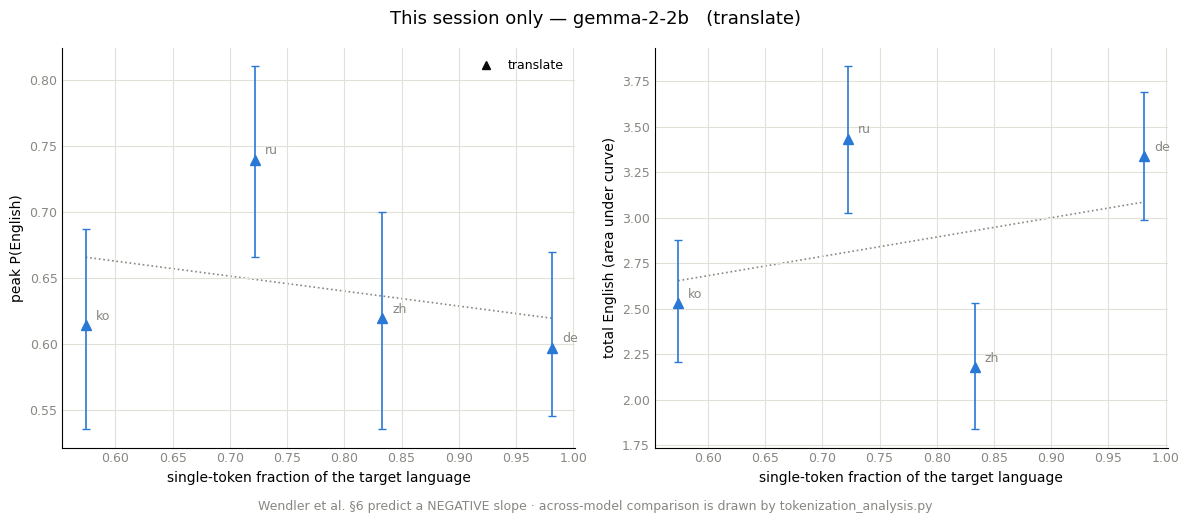

In [15]:
import matplotlib.pyplot as plt

# Session sanity plot: this model, its languages, both tasks. Deliberately NOT named
# fig_tokenization_correlation.png -- that name belongs to tokenization_analysis.py,
# which draws the same axes over every model once all sessions are extracted. Two
# writers on one name means whichever ran last silently becomes "the figure", and
# the single-model version would win by being extracted afterwards.
MIN_ACC = 0.7
keys  = [k for k in SUMM if RESULTS[k]["accuracy"] >= MIN_ACC]
mods  = sorted({k[0] for k in keys})
tasks = [t for t in TASKS if any(k[2] == t for k in keys)]
x     = np.array([RESULTS[k]["single_token_frac"] for k in keys])

# Task is encoded as marker shape, model as colour, so a session running both tasks
# on one model still reads as two series rather than one cloud.
MARK = {"repeat": "o", "translate": "^"}

if not keys:
    print("nothing passes the behavioural gate this session -- no plot.")
else:
    dropped = [k for k in SUMM if k not in keys]
    print(f"{len(keys)}/{len(SUMM)} cells pass the behavioural gate (>= {MIN_ACC:.0%})")
    for k in dropped:
        print(f"   excluded {k[2]}/{k[1]}: acc {RESULTS[k]['accuracy']:.0%} -- the model "
              f"cannot do this task, so its curve is not evidence about the detour")
    CMAP = dict(zip(mods, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, stat, lab in ((axes[0], "peak", "peak P(English)"),
                          (axes[1], "auc",  "total English (area under curve)")):
        for k in keys:
            s  = SUMM[k]
            xi = RESULTS[k]["single_token_frac"]
            yi, l, h = s[stat], s[stat + "_lo"], s[stat + "_hi"]
            ax.errorbar(xi, yi, yerr=[[yi - l], [h - yi]], fmt=MARK.get(k[2], "s"),
                        ms=7, color=CMAP[k[0]], capsize=3, lw=1.2)
            ax.annotate(k[1], (xi, yi), textcoords="offset points",
                        xytext=(7, 4), fontsize=9, color="#898781")
        # One trend line per task: pooling the two would fit a line through two
        # different conditions and describe neither.
        for t in tasks:
            kt = [k for k in keys if k[2] == t]
            xt = np.array([RESULTS[k]["single_token_frac"] for k in kt])
            yt = np.array([SUMM[k][stat] for k in kt])
            if len(set(xt)) > 2:
                b, a = np.polyfit(xt, yt, 1)
                xs = np.linspace(xt.min(), xt.max(), 10)
                ax.plot(xs, a + b * xs, ls="--" if t == "repeat" else ":",
                        lw=1.2, color="#898781", zorder=0)
        ax.set_xlabel("single-token fraction of the target language")
        ax.set_ylabel(lab)
        ax.grid(True, color="#e1e0d9", lw=0.8)
        ax.set_axisbelow(True)
        for s_ in ("top", "right"):
            ax.spines[s_].set_visible(False)
        ax.tick_params(colors="#898781", labelsize=9, length=0)

    handles = [plt.Line2D([], [], marker=MARK.get(t, "s"), ls="", color="#0b0b0b",
                          label=t) for t in tasks]
    if len(mods) > 1:
        handles += [plt.Line2D([], [], marker="o", ls="", color=CMAP[m],
                               label=m.split("/")[-1]) for m in mods]
    axes[0].legend(handles=handles, frameon=False, fontsize=9)
    fig.suptitle(f"This session only — {', '.join(m.split('/')[-1] for m in mods)}"
                 f"   ({', '.join(tasks)})", fontsize=13)
    fig.text(0.5, -0.02, "Wendler et al. §6 predict a NEGATIVE slope · "
             "across-model comparison is drawn by tokenization_analysis.py",
             ha="center", fontsize=9, color="#898781")
    fig.tight_layout()
    fig.savefig(OUT / "fig_tokenization_session.png", dpi=150, bbox_inches="tight")
    plt.show()

In [16]:
from scipy import stats

# Within-session analysis only: one model per kernel means this cell can never see
# more than one tokenizer. The across-model comparison -- the cleaner test, and the
# one this notebook exists for -- is computed locally by tokenization_analysis.py
# once every session's arrays have been extracted. Nothing here substitutes for it.

def correlate(ks, stat, label, indent="   "):
    if len({RESULTS[k]["single_token_frac"] for k in ks}) < 3:
        print(f"{indent}{label:<26} only {len(ks)} cell(s) / too few distinct STF values")
        return
    xi = [RESULTS[k]["single_token_frac"] for k in ks]
    yi = [SUMM[k][stat] for k in ks]
    rho, p_s = stats.spearmanr(xi, yi)
    print(f"{indent}{label:<26} rho = {rho:+.3f}  (p = {p_s:.3f}, n = {len(ks)})  "
          f"observed {'NEGATIVE' if rho < 0 else 'POSITIVE'}")

if not keys:
    print("no usable cells this session -- no correlation to report.")
else:
    print("Wendler et al. §6 predict a NEGATIVE relationship: more single-token")
    print("availability, weaker English detour.\n")

    # The tasks are separate experiments and are never pooled. Repetition is where
    # Wendler's claim is stated; translation is the condition Phase 1 measured. A
    # correlation over both at once would be describing neither.
    for t in tasks:
        ks = [k for k in keys if k[2] == t]
        print(f"{t}  ({len(ks)} languages)")
        correlate(ks, "peak", "peak P(English)")
        correlate(ks, "auc",  "total English (AUC)")
        print()

    # Does the tokenization relationship even have the same sign in the two tasks?
    # If it does not, "the detour" is not one phenomenon with one explanation.
    if len(tasks) == 2:
        print("same-language comparison across tasks (translation - repetition):")
        both = sorted({k[1] for k in keys if k[2] == "repeat"} &
                      {k[1] for k in keys if k[2] == "translate"})
        if not both:
            print("   no language has both tasks this session")
        for lg in both:
            kr = next(k for k in keys if k[1] == lg and k[2] == "repeat")
            kt = next(k for k in keys if k[1] == lg and k[2] == "translate")
            print(f"   {lg}:  peak {SUMM[kt]['peak'] - SUMM[kr]['peak']:+.3f}   "
                  f"AUC {SUMM[kt]['auc'] - SUMM[kr]['auc']:+.3f}")
        print("   (paired CIs for this comparison come from tokenization_analysis.py)")

    print("\nwithin language, across models (same words, different tokenizers):")
    print("   not computable in one session by construction -- run the notebook again")
    print("   on another model, then: python tokenization_analysis.py")

Wendler et al. §6 predict a NEGATIVE relationship: more single-token
availability, weaker English detour.

translate  (4 languages)
   peak P(English)            rho = -0.400  (p = 0.600, n = 4)  observed NEGATIVE
   total English (AUC)        rho = +0.000  (p = 1.000, n = 4)  observed POSITIVE


within language, across models (same words, different tokenizers):
   not computable in one session by construction -- run the notebook again
   on another model, then: python tokenization_analysis.py


### Interpreting this honestly

- **n is small.** With a handful of (model, language) cells, a correlation
  coefficient is a description of these points, not an estimate of a population
  parameter. Report the scatter; do not lean on the p-value.
- **The cells are not independent.** Cells sharing a model share a tokenizer and
  training corpus; cells sharing a language share a word list. The pooled
  correlation double-counts. The two stratified breakdowns above are the honest
  version, and the within-language one is the strongest evidence available here
  because it holds everything but the tokenizer fixed.
- **A positive or null result is informative.** Wendler's conjecture predicts
  negative. Anything else says single-token availability is not what drives the
  effect — which is what the Estonian result in their own Appendix B.1 already
  hints at, Estonian being 1% single-token yet behaving like Chinese at 100%.

## The shared-character control

For concepts written identically in Japanese and Chinese, the target token is
the same token. Single-token availability is therefore held *exactly* constant,
not merely approximately, and only the language framing of the prompt differs.

If the English detour differs on this subset, tokenization cannot be the cause.

In [17]:
shared_ja = {w[COL["ja"]] for w in WORDS if w[COL["ja"]] == w[COL["zh"]]}

def shared_subset(r):
    '''Mean English curve over only the words whose JA and ZH forms are identical.'''
    pw = np.stack([r["curves"][r["widx"] == u].mean(0) for u in np.unique(r["widx"])])
    mask = np.array([w in shared_ja for w in r["words"]])   # r["words"] is sweep order
    return (mask.sum(), pw[mask][:, :, 1].mean(0)) if mask.any() else (0, None)

# REPETITION ONLY, and this is not a limitation of the code -- it is what the control
# means. The comparison works because the same character is the answer under both
# language framings. In the translation task those very concepts are dropped by
# run_language, because a JA->ZH prompt whose answer equals its question is a copy,
# not a translation. So the shared-character control exists for repetition and cannot
# exist for translation; there is no version of it to run.
done = False
if keys:
    print(f"{len(shared_ja)} concepts share a character between JA and ZH\n")
    for name in mods:
        kj, kz = (name, "ja", "repeat"), (name, "zh", "repeat")
        if kj not in RESULTS or kz not in RESULTS:
            continue
        n_ja, en_ja = shared_subset(RESULTS[kj])
        n_zh, en_zh = shared_subset(RESULTS[kz])
        if en_ja is None or en_zh is None:
            continue
        print(f"{name.split('/')[-1]}   (identical target tokens, only the prompt label differs)")
        print(f"   ja  n={n_ja:2}  peak P(EN) {en_ja.max():.3f}   AUC {en_ja.sum():.3f}")
        print(f"   zh  n={n_zh:2}  peak P(EN) {en_zh.max():.3f}   AUC {en_zh.sum():.3f}")
        print(f"   difference  peak {en_ja.max()-en_zh.max():+.3f}   "
              f"AUC {en_ja.sum()-en_zh.sum():+.3f}")
        print("   -> any nonzero difference here cannot be tokenization\n")
        done = True
if not done:
    print("shared-character control needs ja AND zh swept on one model under the")
    print("REPETITION task -- not available this session, skipped.")
print("Confidence intervals for this comparison come from tokenization_analysis.py,")
print("which resamples the shared concepts paired across the two language framings.")

17 concepts share a character between JA and ZH

shared-character control needs ja AND zh swept on one model under the
REPETITION task -- not available this session, skipped.
Confidence intervals for this comparison come from tokenization_analysis.py,
which resamples the shared concepts paired across the two language framings.


## Send results back to VS Code

The kernel runs on a remote GPU whose filesystem is destroyed with the session,
so `np.save()` writes into a container that is about to vanish — an earlier run's
arrays were lost exactly that way. Nothing here writes to that disk and nothing
pushes from inside it.

The one channel that reaches a local machine is the notebook's **own output**,
which is a local file. So the arrays are packed into an npz, base64-encoded, and
printed. Afterwards, locally:

```
python extract_results.py tokenization_vs_detour.ipynb
python tokenization_analysis.py
```

Figures need no help — matplotlib embeds them in the notebook automatically and
the same script pulls them out.

**Run this cell even if the sweep only covered one model.** Output files are
tagged by model, so a second session's results land beside the first rather than
on top of them.

In [18]:
# Emit results back through the notebook's OWN OUTPUT, not the kernel's disk.
#
# Arrays are keyed "<model>__<lang>__<task>__curves" / "__widx", so running this
# notebook once per (model, task set) produces disjoint keys and the sessions merge
# by themselves. The scalar metadata rides alongside as JSON under "<model>|<lang>|
# <task>", tagged with the model AND the tasks, so a translate-only session cannot
# overwrite the summary written by an earlier repeat-only session.
#
# The old two-part naming ("<model>__<lang>__curves", meta key "<model>|<lang>") is
# still readable downstream and is treated as task="repeat", which is what it was.
import base64, io
import json as _json
import numpy as np

if not RESULTS:
    # A guard, not an assert. Nothing to emit is a legitimate outcome when the gate
    # refused the model, and raising here would stop Run All at the very last cell
    # for no benefit.
    print("RESULTS is empty -- nothing to emit. The gate refused this session's model;")
    print("read the diagnostic cell above. Nothing has been written or overwritten.")
else:
    ARRAYS = {}
    for (name, lang, task), r in RESULTS.items():
        tag = f"{name.split('/')[-1]}__{lang}__{task}"
        ARRAYS[tag + "__curves"] = r["curves"]
        ARRAYS[tag + "__widx"]   = r["widx"]

    meta = {f"{k[0]}|{k[1]}|{k[2]}": {kk: vv for kk, vv in v.items()
                                      if kk not in ("curves", "widx", "labels")}
            for k, v in RESULTS.items()}

    # Which models AND tasks this session swept -- becomes results/summary_<TAG>.json.
    # The task is part of the tag because a second session on the same model with the
    # other task would otherwise land on the first session's summary file and delete
    # the metadata its arrays depend on, leaving orphaned .npy files that the analysis
    # script skips with a warning nobody reads.
    m_tag = "_".join(sorted({k[0].split("/")[-1] for k in RESULTS}))
    t_tag = "_".join(sorted({k[2] for k in RESULTS}))
    TAG   = f"{m_tag}__{t_tag}"
    ARRAYS[f"_meta_json__{TAG}"] = np.frombuffer(
        _json.dumps(meta, ensure_ascii=False).encode(), dtype=np.uint8)

    buf = io.BytesIO()
    np.savez_compressed(buf, **ARRAYS)
    raw = buf.getvalue()
    b64 = base64.b64encode(raw).decode()

    print(f"#RESULTS_NPZ_B64# {len(ARRAYS)} arrays, {len(raw)/1024:.1f} KB packed  [{TAG}]")
    for i in range(0, len(b64), 4000):    # chunked: avoids any single-line limits
        print(b64[i:i + 4000])
    print("#END_RESULTS_NPZ_B64#")
    print()
    print("SAVE THE NOTEBOOK FIRST -- extract_results.py reads this file from disk,")
    print("so running it before the save finds the previous session's output.")
    print("Check the saved file actually kept its outputs before closing the tab:")
    print("   python -c \"import json;nb=json.load(open('tokenization_vs_detour.ipynb',encoding='utf-8'));print(sum(len(c.get('outputs',[])) for c in nb['cells']),'outputs')\"")
    print("   python extract_results.py tokenization_vs_detour.ipynb")
    print("   python tokenization_analysis.py")

#RESULTS_NPZ_B64# 9 arrays, 122.8 KB packed  [gemma-2-2b__translate]
...
#END_RESULTS_NPZ_B64#

SAVE THE NOTEBOOK FIRST -- extract_results.py reads this file from disk,
so running it before the save finds the previous session's output.
Check the saved file actually kept its outputs before closing the tab:
   python -c "import json;nb=json.load(open('tokenization_vs_detour.ipynb',encoding='utf-8'));print(sum(len(c.get('outputs',[])) for c in nb['cells']),'outputs')"
   python extract_results.py tokenization_vs_detour.ipynb
   python tokenization_analysis.py
